<a href="https://colab.research.google.com/github/rvit22bcs044rvitm-cod/Potato-Leaf-Disease-Classification-using-CNN/blob/main/code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Extraction Complete!
Found 2152 files belonging to 3 classes.
Using 1722 files for training.
Found 2152 files belonging to 3 classes.
Using 430 files for validation.
Classes found: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


54/54 ━━━━━━━━━━━━━━━━━━━━ 259s 5s/step - accuracy: 0.7195 - loss: 0.7161 - val_accuracy: 0.8592 - val_loss: 0.3875
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 248s 4s/step - accuracy: 0.8461 - loss: 0.4434 - val_accuracy: 0.8689 - val_loss: 0.3038
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 271s 5s/step - accuracy: 0.8786 - loss: 0.3155 - val_accuracy: 0.9126 - val_loss: 0.2277
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 251s 4s/step - accuracy: 0.9106 - loss: 0.2481 - val_accuracy: 0.9563 - val_loss: 0.1611
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 253s 5s/step - accuracy: 0.9384 - loss: 0.1578 - val_accuracy: 0.9320 - val_loss: 0.1524
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 251s 4s/step - accuracy: 0.9553 - loss: 0.1201 - val_accuracy: 0.8786 - val_loss: 0.3129
Epoch 7/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 247s 5s/step - accuracy: 0.9431 - loss: 0.1614 - val_accuracy: 0.8689 - val_loss: 0.3440
Epoch 8/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 265s 5s/step - accuracy: 0.9559 - loss: 0.1308 - val_accuracy: 0.9515 - val_loss: 0.

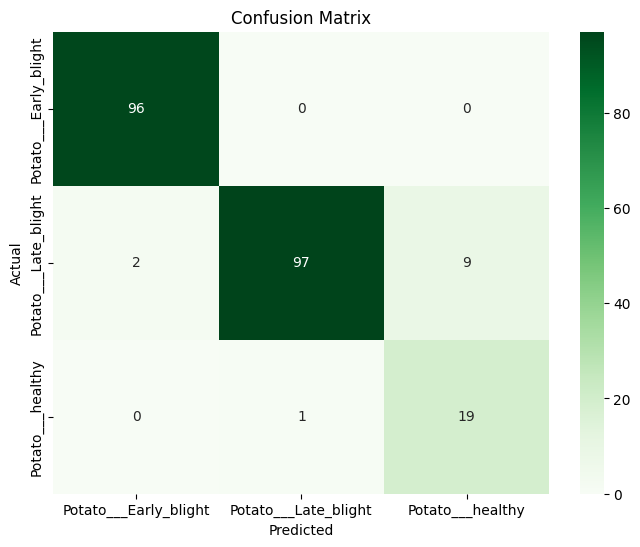

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os
import zipfile
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

ZIP_FILE = '/content/potato_data.zip'
EXTRACT_DIR = '/content/potato_dataset'

if os.path.exists(ZIP_FILE):
    with zipfile.ZipFile(ZIP_FILE, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

    macosx_dir = os.path.join(EXTRACT_DIR, "__MACOSX")
    if os.path.exists(macosx_dir):
        import shutil
        shutil.rmtree(macosx_dir)
    print("Extraction Complete!")
else:
    print(f"ERROR: Upload {ZIP_FILE} first.")

# --- 2. CONFIGURATION ---
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 20
SEED = 42
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    EXTRACT_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    EXTRACT_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
)

class_names = train_ds.class_names
print(f"Classes found: {class_names}")

val_batches = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take(val_batches // 2)
val_ds = val_ds.skip(val_batches // 2)


train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)


data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
])


model = models.Sequential([
    layers.InputLayer(input_shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)),
    layers.Rescaling(1./255), # Normalization
    data_augmentation,        # Only active during training

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=1
)


print("\n--- FINAL EVALUATION ---")
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc*100:.2f}%")

y_true = []
y_pred = []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()